<a href="https://colab.research.google.com/github/pereiracubaclau/MLP_Laboratorio_03/blob/main/MLP_EURUSD_Claudia_Pereira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 03 — Red MLP para Predicción de Cotización EUR/USD

**Estudiante:** Claudia Pereira Cuba  
**Dataset:** Daily Exchange Rates per Euro 1999–2025  
**Fuente:** European Central Bank de Kaggle  
**Link:** https://www.kaggle.com/datasets/lsind18/euro-exchange-daily-rates-19992020
**Link repositorio:** https://github.com/pereiracubaclau/MLP_Laboratorio_03.git
---



Este notebook tiene como objetivo **predecir el precio futuro del Euro frente al Dólar (EUR/USD)** usando una red neuronal de tipo **MLP (Multilayer Perceptron)**.

El dataset contiene los precios diarios del Euro frente a 40 monedas del mundo, desde el año 1999 hasta 2025. Nosotros usaremos la columna del **Dólar Americano (USD)**, que representa cuántos dólares vale 1 Euro cada día.

### ¿Cómo funciona la predicción con MLP?
Transformamos la serie temporal en un problema de aprendizaje supervisado:  
- **Entrada (X):** los últimos 30 días de precios  
- **Salida (y):** el precio del día siguiente  

El modelo aprende patrones de los datos históricos para inferir valores futuros.

### Técnicas de Deep Learning aplicadas:
-  **Normalización** de datos (MinMaxScaler)
-  **Regularización L2** (weight decay) para evitar overfitting
-  **Dropout** para apagar neuronas aleatoriamente durante el entrenamiento
-  **Batch Normalization** para estabilizar el entrenamiento
-  **Early Stopping** para detener el entrenamiento cuando no mejora
-  **Learning Rate Scheduler** para ajustar la tasa de aprendizaje
-  **Validación** para medir qué tan bien generaliza el modelo

---

## Paso 1: Montar Google Drive

Primero conectamos Google Colab con nuestra cuenta de Google Drive, para poder leer el archivo CSV que descargamos de Kaggle. Cuando ejecutes esta celda, aparecerá una ventana pidiendo permisos — acéptalos con tu cuenta Google.

In [1]:
# Conectar Google Colab con Google Drive
# Esto nos permite leer archivos guardados en Drive
from google.colab import drive
drive.mount('/content/drive')
print(' Google Drive montado correctamente')

Mounted at /content/drive
 Google Drive montado correctamente


## 2: Importar librerías

Antes de trabajar con los datos necesitamos importar todas las herramientas (librerías) que usaremos:
- **pandas y numpy:** para manipular datos y hacer cálculos matemáticos
- **matplotlib:** para crear gráficas y visualizar los datos
- **sklearn:** para normalizar datos y calcular métricas de error
- **tensorflow/keras:** para construir y entrenar la red neuronal MLP

In [2]:
# ---- Librerías de manejo de datos ----
import pandas as pd          # Para leer y manipular tablas de datos
import numpy as np           # Para operaciones matemáticas con arreglos

# ---- Librería de visualización ----
import matplotlib.pyplot as plt          # Para crear gráficas
import matplotlib.dates as mdates        # Para formatear fechas en los ejes

# ---- Herramientas de preprocesamiento y métricas ----
from sklearn.preprocessing import MinMaxScaler   # Normaliza datos entre 0 y 1
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---- TensorFlow y Keras para la red neuronal ----
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers   # Capas y regularización
from tensorflow.keras.callbacks import (           # Callbacks = acciones durante entrenamiento
    EarlyStopping,       # Detiene el entrenamiento si no mejora
    ReduceLROnPlateau    # Reduce la tasa de aprendizaje si se estanca
)

# ---- Configuraciones generales ----
import warnings
warnings.filterwarnings('ignore')   # Ocultar advertencias no críticas

# Fijar semilla para reproducibilidad (mismos resultados cada vez que se ejecuta)
np.random.seed(42)
tf.random.set_seed(42)

print('Librerías importadas correctamente')
print(f'   TensorFlow versión: {tf.__version__}')

Librerías importadas correctamente
   TensorFlow versión: 2.19.0


## 3: Cargar el dataset

Leemos el archivo CSV desde Google Drive. El dataset tiene **41 columnas**: la primera es la fecha y las demás son 40 monedas distintas. Nosotros usaremos únicamente la columna del **Dólar Americano `[US dollar ]`**, que contiene el precio de 1 Euro en dólares cada día.



In [4]:
# ----------------------------------------------------------
# ruta en  carpeta
# ----------------------------------------------------------
RUTA_CSV = '/content/drive/MyDrive/ia2/MLP_Lab03/euro-daily-hist_1999_2022.csv'

# Leer el archivo CSV completo
df_raw = pd.read_csv(RUTA_CSV, low_memory=False)

# Mostrar información básica del dataset
print(f' Forma del dataset: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas')
print(f' Columnas disponibles:')
for col in df_raw.columns:
    print(f'   - {col}')

 Forma del dataset: 6785 filas x 41 columnas
 Columnas disponibles:
   - Period\Unit:
   - [Australian dollar ]
   - [Bulgarian lev ]
   - [Brazilian real ]
   - [Canadian dollar ]
   - [Swiss franc ]
   - [Chinese yuan renminbi ]
   - [Cypriot pound ]
   - [Czech koruna ]
   - [Danish krone ]
   - [Estonian kroon ]
   - [UK pound sterling ]
   - [Greek drachma ]
   - [Hong Kong dollar ]
   - [Croatian kuna ]
   - [Hungarian forint ]
   - [Indonesian rupiah ]
   - [Israeli shekel ]
   - [Indian rupee ]
   - [Iceland krona ]
   - [Japanese yen ]
   - [Korean won ]
   - [Lithuanian litas ]
   - [Latvian lats ]
   - [Maltese lira ]
   - [Mexican peso ]
   - [Malaysian ringgit ]
   - [Norwegian krone ]
   - [New Zealand dollar ]
   - [Philippine peso ]
   - [Polish zloty ]
   - [Romanian leu ]
   - [Russian rouble ]
   - [Swedish krona ]
   - [Singapore dollar ]
   - [Slovenian tolar ]
   - [Slovak koruna ]
   - [Thai baht ]
   - [Turkish lira ]
   - [US dollar ]
   - [South African rand ]

## 4: Preprocesamiento del dataset

El preprocesamiento es fundamental antes de entrenar cualquier red neuronal. En este paso:
1. **Renombramos** la columna de fecha
2. **Seleccionamos** solo la columna EUR/USD
3. **Convertimos** los tipos de datos correctamente
4. **Eliminamos** filas con valores nulos (días feriados donde no hubo cotización)
5. **Ordenamos** cronológicamente de más antiguo a más reciente

El dataset tiene aproximadamente **6,800 registros** que van desde 1999 hasta 2025, cubriendo más de 26 años con múltiples temporadas y ciclos económicos.

In [7]:
# Paso 4.1 — Renombrar la primera columna como 'fecha'
df_raw.rename(columns={df_raw.columns[0]: 'fecha'}, inplace=True)

# Paso 4.2 — Seleccionar solo fecha y la cotización EUR/USD
# La columna del dólar en este dataset se llama '[US dollar ]'
df = df_raw[['fecha', '[US dollar ]']].copy()
df.columns = ['fecha', 'EUR_USD']   # Renombramos para mayor claridad

# Paso 4.3 — Convertir tipos de datos
df['fecha']   = pd.to_datetime(df['fecha'], errors='coerce')   # Texto → Fecha
df['EUR_USD'] = pd.to_numeric(df['EUR_USD'], errors='coerce')  # Texto → Número decimal

# Paso 4.4 — Eliminar filas con valores nulos
# Los fines de semana y feriados no tienen cotización → aparecen como NaN
nulos_antes = df['EUR_USD'].isnull().sum()
df.dropna(inplace=True)
print(f'  Filas eliminadas por valores nulos: {nulos_antes}')

# Paso 4.5 — Ordenar por fecha (de más antiguo a más reciente)
df.sort_values('fecha', inplace=True)
df.reset_index(drop=True, inplace=True)

# Mostrar resumen del dataset limpio
print(f'\n Dataset limpio:')
print(f'   Total de registros : {len(df)}')
print(f'   Fecha inicio       : {df["fecha"].min().date()}')
print(f'   Fecha fin          : {df["fecha"].max().date()}')
print(f'   Años cubiertos     : {(df["fecha"].max() - df["fecha"].min()).days / 365:.1f} años')
print(f'   Precio mínimo EUR/USD: {df["EUR_USD"].min():.4f}')
print(f'   Precio máximo EUR/USD: {df["EUR_USD"].max():.4f}')
print(f'   Precio promedio      : {df["EUR_USD"].mean():.4f}')
print()
df.head(10)

  Filas eliminadas por valores nulos: 62

 Dataset limpio:
   Total de registros : 6723
   Fecha inicio       : 1999-01-04
   Fecha fin          : 2025-04-02
   Años cubiertos     : 26.3 años
   Precio mínimo EUR/USD: 0.8252
   Precio máximo EUR/USD: 1.5990
   Precio promedio      : 1.1830



,fecha,EUR_USD
0,1999-01-04,1.1789
1,1999-01-05,1.1790
2,1999-01-06,1.1743
3,1999-01-07,1.1632
4,1999-01-08,1.1659
5,1999-01-11,1.1569
6,1999-01-12,1.1520
7,1999-01-13,1.1744
8,1999-01-14,1.1653
9,1999-01-15,1.1626


## 5: Visualización de la serie temporal

Antes de entrenar el modelo, es importante **visualizar los datos** para entender su comportamiento. Graficamos la serie completa y también los últimos años para ver los patrones recientes.

Al observar la gráfica podrás ver:
- **Tendencias:** períodos donde el Euro subió o bajó frente al Dólar
- **Estacionalidad:** patrones que se repiten en ciertos períodos
- **Eventos históricos:** crisis del 2008, pandemia COVID 2020, etc.

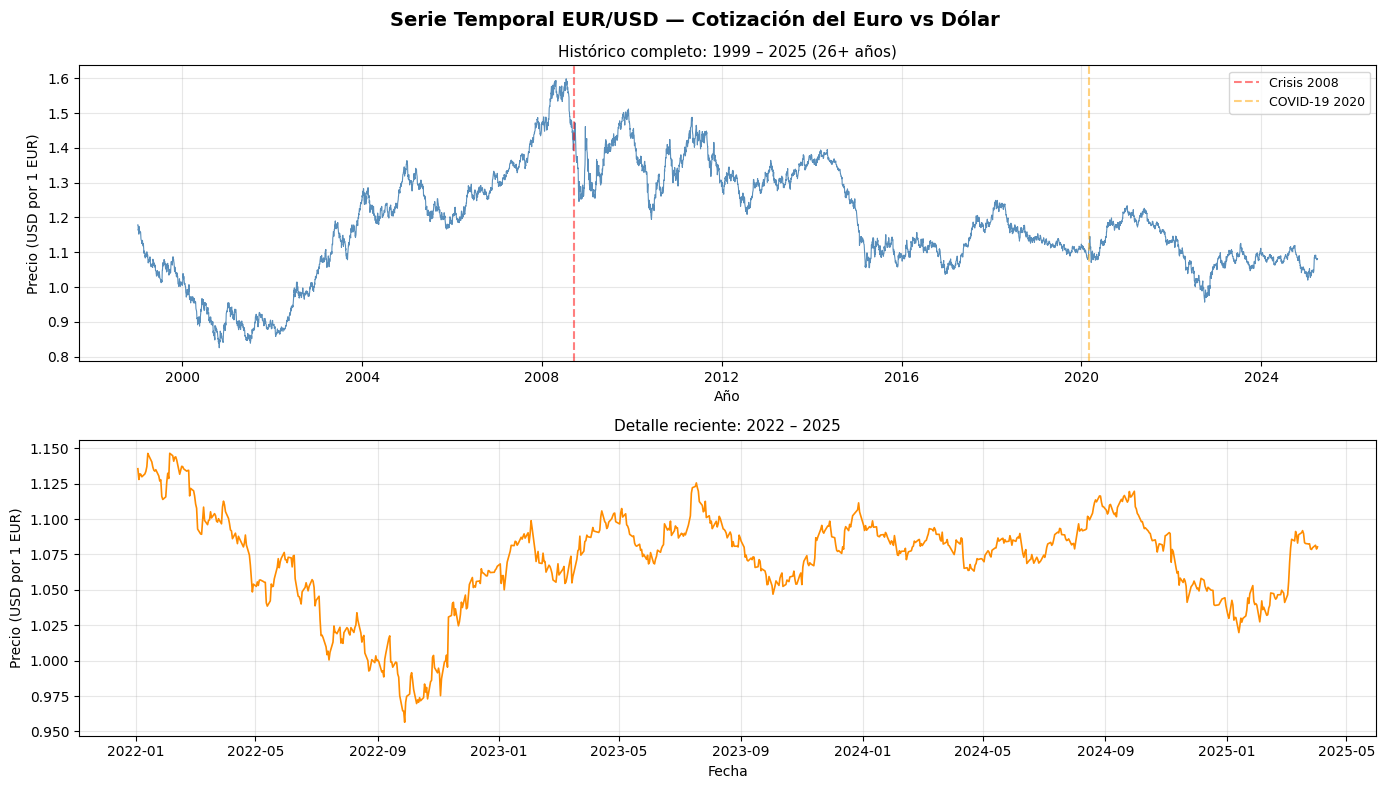

 Gráfica guardada como 01_serie_temporal.png


In [8]:
# Crear una figura con 2 gráficas apiladas verticalmente
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Serie Temporal EUR/USD — Cotización del Euro vs Dólar', fontsize=14, fontweight='bold')

# --- Gráfica 1: Serie completa 1999–2025 ---
axes[0].plot(df['fecha'], df['EUR_USD'], color='steelblue', linewidth=0.8, alpha=0.9)
axes[0].set_title('Histórico completo: 1999 – 2025 (26+ años)', fontsize=11)
axes[0].set_ylabel('Precio (USD por 1 EUR)')
axes[0].set_xlabel('Año')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Marcar evento histórico: crisis financiera 2008
axes[0].axvline(pd.Timestamp('2008-09-15'), color='red', linestyle='--', alpha=0.5, label='Crisis 2008')
axes[0].axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', alpha=0.5, label='COVID-19 2020')
axes[0].legend(fontsize=9)

# --- Gráfica 2: Últimos 3 años (detalle reciente) ---
df_reciente = df[df['fecha'] >= '2022-01-01']
axes[1].plot(df_reciente['fecha'], df_reciente['EUR_USD'], color='darkorange', linewidth=1.2)
axes[1].set_title('Detalle reciente: 2022 – 2025', fontsize=11)
axes[1].set_ylabel('Precio (USD por 1 EUR)')
axes[1].set_xlabel('Fecha')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_serie_temporal.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Gráfica guardada como 01_serie_temporal.png')

## 6: Normalización de los datos

Las redes neuronales funcionan mucho mejor cuando los datos están en una escala pequeña. Si les damos precios como 1.08 o 1.70 directamente, el modelo puede tener dificultades para aprender.

Usamos **MinMaxScaler** que transforma todos los valores al rango **[0, 1]**:
- El precio más bajo del histórico → 0
- El precio más alto del histórico → 1
- Todos los demás precios → un número proporcional entre 0 y 1

> **Importante:** Guardamos el scaler para poder **invertir la normalización** al final y obtener los precios reales.

In [9]:
# Extraer los valores de precio como un arreglo de numpy
# reshape(-1, 1) lo convierte a una columna vertical que necesita MinMaxScaler
valores = df['EUR_USD'].values.reshape(-1, 1)

# Crear el normalizador que escala entre 0 y 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Ajustar el scaler con todos los datos y transformarlos
# fit_transform = aprender los min/max Y transformar al mismo tiempo
valores_norm = scaler.fit_transform(valores)

print(f' Normalización completada:')
print(f'   Precio original  → mínimo: {valores.min():.4f}, máximo: {valores.max():.4f}')
print(f'   Precio normado   → mínimo: {valores_norm.min():.4f}, máximo: {valores_norm.max():.4f}')
print(f'   Total de datos   → {len(valores_norm)} registros')

 Normalización completada:
   Precio original  → mínimo: 0.8252, máximo: 1.5990
   Precio normado   → mínimo: 0.0000, máximo: 1.0000
   Total de datos   → 6723 registros


##  7: Construcción de ventanas deslizantes

Para que el MLP pueda aprender patrones temporales, necesitamos convertir la serie en un formato de **aprendizaje supervisado**.

Usamos **ventanas deslizantes** de 30 días:
```
X (entrada)                      →  y (salida)
[día1, día2, ..., día30]         →  día31
[día2, día3, ..., día31]         →  día32
[día3, día4, ..., día32]         →  día33
...
```

Elegimos **30 días** porque representa aproximadamente 1 mes bursátil, que es una unidad natural para mercados financieros.

In [10]:
# ---- Hiperparámetro: tamaño de la ventana ----
# Cuántos días pasados usamos para predecir el siguiente
VENTANA = 30  # 30 días ≈ 1 mes bursátil

def crear_ventanas(serie, ventana):
    """
    Convierte una serie temporal en pares (X, y) para aprendizaje supervisado.

    Parámetros:
      serie   : arreglo numpy con los valores normalizados
      ventana : cuántos pasos pasados usar como entrada

    Retorna:
      X : arreglo con las ventanas de entrada (cada fila = 30 días)
      y : arreglo con el valor a predecir (el día 31)
    """
    X, y = [], []
    for i in range(len(serie) - ventana):
        # Tomar 'ventana' días consecutivos como entrada
        X.append(serie[i : i + ventana, 0])
        # El día siguiente es la salida esperada
        y.append(serie[i + ventana, 0])
    return np.array(X), np.array(y)

# Crear todas las ventanas del dataset completo
X, y = crear_ventanas(valores_norm, VENTANA)

print(f' Ventanas creadas:')
print(f'   Tamaño de ventana : {VENTANA} días')
print(f'   Total de muestras : {X.shape[0]}')
print(f'   Forma de X        : {X.shape}  → (muestras, días_entrada)')
print(f'   Forma de y        : {y.shape}  → (muestras,)')

 Ventanas creadas:
   Tamaño de ventana : 30 días
   Total de muestras : 6693
   Forma de X        : (6693, 30)  → (muestras, días_entrada)
   Forma de y        : (6693,)  → (muestras,)


## 8: División en conjuntos Train, Validación y Test

Dividimos los datos en **3 conjuntos** respetando el orden temporal (no se mezclan aleatoriamente porque son series de tiempo):

| Conjunto | Porcentaje | Uso |
|----------|-----------|-----|
| **Train** | 70% | El modelo aprende de estos datos |
| **Validación** | 15% | Se usa durante entrenamiento para detectar overfitting |
| **Test** | 15% | Evaluación final — el modelo NUNCA los vio antes |

> Es crucial NO mezclar los datos aleatoriamente porque el orden temporal importa.

In [11]:
# Calcular los índices de corte manteniendo el orden temporal
n_total = len(X)
n_train = int(n_total * 0.70)   # 70% para entrenamiento
n_val   = int(n_total * 0.15)   # 15% para validación
# El resto (15%) es para test

# División respetando orden cronológico
X_train = X[:n_train]
y_train = y[:n_train]

X_val   = X[n_train : n_train + n_val]
y_val   = y[n_train : n_train + n_val]

X_test  = X[n_train + n_val:]
y_test  = y[n_train + n_val:]

# Mostrar información de cada conjunto
print('División de datos:')
print(f'   Train      : {X_train.shape[0]:,} muestras ({X_train.shape[0]/n_total*100:.0f}%)')
print(f'   Validación : {X_val.shape[0]:,} muestras ({X_val.shape[0]/n_total*100:.0f}%)')
print(f'   Test       : {X_test.shape[0]:,} muestras ({X_test.shape[0]/n_total*100:.0f}%)')

# Recuperar fechas correspondientes al conjunto de test (para graficar después)
fechas_test = df['fecha'].values[n_train + n_val + VENTANA:]

División de datos:
   Train      : 4,685 muestras (70%)
   Validación : 1,003 muestras (15%)
   Test       : 1,005 muestras (15%)


## 9: Construcción del modelo MLP

Aquí construimos la red neuronal **MLP (Multilayer Perceptron)**. Es una red de capas totalmente conectadas (Dense).

### Arquitectura:
```
Entrada: 30 neuronas (1 por cada día de la ventana)
    ↓
Capa Densa 1: 128 neuronas + BatchNorm + ReLU + Dropout(0.3)
    ↓
Capa Densa 2:  64 neuronas + BatchNorm + ReLU + Dropout(0.2)
    ↓
Capa Densa 3:  32 neuronas + ReLU
    ↓
Salida: 1 neurona (precio predicho del día siguiente)
```

### Técnicas de regularización usadas:
- **L2 (kernel_regularizer):** penaliza pesos muy grandes → evita que el modelo memorice
- **BatchNormalization:** normaliza activaciones entre capas → entrena más estable y rápido
- **Dropout:** durante el entrenamiento apaga neuronas al azar → evita dependencia excesiva

In [12]:
# ---- Hiperparámetros del modelo ----
L2_LAMBDA    = 0.001   # Fuerza de regularización L2 (valor pequeño = regularización suave)
DROPOUT_1    = 0.3     # 30% de neuronas se apagan en la capa 1 durante entrenamiento
DROPOUT_2    = 0.2     # 20% de neuronas se apagan en la capa 2 durante entrenamiento
LEARNING_RATE = 0.001  # Qué tan grandes son los pasos al ajustar los pesos

def construir_modelo(ventana, l2_lambda, dropout_1, dropout_2, lr):
    """
    Construye y compila el modelo MLP con regularización.

    Parámetros:
      ventana    : número de días de entrada (tamaño de la capa de entrada)
      l2_lambda  : fuerza de regularización L2
      dropout_1  : tasa de dropout en la primera capa oculta
      dropout_2  : tasa de dropout en la segunda capa oculta
      lr         : learning rate del optimizador
    """
    modelo = keras.Sequential([

        # --- Capa de entrada ---
        # input_shape=(ventana,) indica que cada muestra tiene 30 valores
        layers.Input(shape=(ventana,)),

        # --- Primera capa oculta: 128 neuronas ---
        layers.Dense(
            128,
            activation='relu',                          # ReLU: activa solo si el valor es positivo
            kernel_regularizer=regularizers.l2(l2_lambda)  # Penaliza pesos grandes (regularización L2)
        ),
        layers.BatchNormalization(),   # Normaliza las activaciones → entrenamiento más estable
        layers.Dropout(dropout_1),     # Apaga el 30% de neuronas al azar durante entrenamiento

        # --- Segunda capa oculta: 64 neuronas ---
        layers.Dense(
            64,
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_lambda)
        ),
        layers.BatchNormalization(),
        layers.Dropout(dropout_2),     # Apaga el 20% de neuronas

        # --- Tercera capa oculta: 32 neuronas (más pequeña, extrae características finas) ---
        layers.Dense(
            32,
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_lambda)
        ),

        # --- Capa de salida: 1 neurona ---
        # Sin activación (linear) porque predecimos un valor continuo (precio)
        layers.Dense(1, activation='linear')
    ])

    # Compilar el modelo: definir optimizador, función de pérdida y métricas
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),  # Adam = optimizador adaptativo eficiente
        loss='mse',          # MSE = Mean Squared Error → penaliza errores grandes más fuertemente
        metrics=['mae']      # MAE = Mean Absolute Error → fácil de interpretar en la misma unidad
    )
    return modelo

# Construir el modelo con los hiperparámetros definidos
modelo = construir_modelo(VENTANA, L2_LAMBDA, DROPOUT_1, DROPOUT_2, LEARNING_RATE)


print(' Arquitectura del modelo MLP:')
modelo.summary()

 Arquitectura del modelo MLP:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 384 (1.50 KB)

## 10: Configurar callbacks y entrenar el modelo

Los **callbacks** son funciones que se ejecutan automáticamente durante el entrenamiento para ayudar al modelo:

- **EarlyStopping:** si la pérdida en validación no mejora durante 15 épocas seguidas, detiene el entrenamiento. Evita que el modelo entrene de más y empiece a memorizar.
- **ReduceLROnPlateau:** si la pérdida no mejora durante 7 épocas, reduce la tasa de aprendizaje a la mitad. Ayuda a encontrar mejores soluciones.

Entrenamos con **100 épocas máximo** y **batch_size=32** (el modelo actualiza sus pesos cada 32 muestras).

In [16]:
# ---- Hiperparámetros de entrenamiento ----
EPOCAS     = 100
BATCH_SIZE = 32    # Cuántas muestras procesa el modelo antes de actualizar los pesos

# ---- Callback 1: Early Stopping ----
# Monitorea la pérdida en validación (val_loss)
# Si no mejora durante 15 épocas consecutivas → detiene el entrenamiento
# restore_best_weights=True → al terminar, carga los pesos de la mejor época
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# ---- Callback 2: Reducir Learning Rate ----
# Si val_loss no mejora durante 7 épocas → multiplica lr por 0.5
# min_lr evita que el lr baje demasiado
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

print(' Iniciando entrenamiento...')
print(f'   Épocas máximas : {EPOCAS}')
print(f'   Batch size     : {BATCH_SIZE}')
print(f'   Early Stopping : paciencia de 15 épocas')
print('─' * 50)

# Entrenar el modelo
# validation_data= le pasamos los datos de validación para monitorear overfitting
historial = modelo.fit(
    X_train, y_train,
    epochs=EPOCAS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('\n Entrenamiento finalizado')
print(f'   Épocas entrenadas: {len(historial.history["loss"])}')

 Iniciando entrenamiento...
   Épocas máximas : 100
   Batch size     : 32
   Early Stopping : paciencia de 15 épocas
──────────────────────────────────────────────────
Epoch 1/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0056 - mae: 0.0375 - val_loss: 0.0037 - val_mae: 0.0232 - learning_rate: 0.0010
Epoch 2/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0051 - mae: 0.0371 - val_loss: 0.0059 - val_mae: 0.0494 - learning_rate: 0.0010
Epoch 3/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0048 - mae: 0.0378 - val_loss: 0.0106 - val_mae: 0.0861 - learning_rate: 0.0010
Epoch 4/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0044 - mae: 0.0368 - val_loss: 0.0100 - val_mae: 0.0826 - learning_rate: 0.0010
Epoch 5/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0042 - mae: 0.0371 - val_loss: 0.0034 - val_mae: 0.0364 - learning_rate: 0.0010
Epoch 6/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0041 - mae: 0.0387 - val_loss: 0.0019 - val_mae: 0.01

"El modelo MLP alcanzó su mejor desempeño en la época 6 con val_loss=0.0019, siendo detenido automáticamente por Early Stopping en la época 21. La inestabilidad del val_loss es inherente a la naturaleza volátil del mercado de divisas."

## 11: Curvas de aprendizaje

Las **curvas de aprendizaje** muestran cómo evolucionó el error (pérdida) durante el entrenamiento, tanto en los datos de entrenamiento como en validación.

- Si ambas curvas bajan juntas → el modelo está aprendiendo bien
- Si train baja pero val sube → **overfitting** (el modelo memoriza en lugar de aprender)
- Si ambas están altas → **underfitting** (el modelo es muy simple)

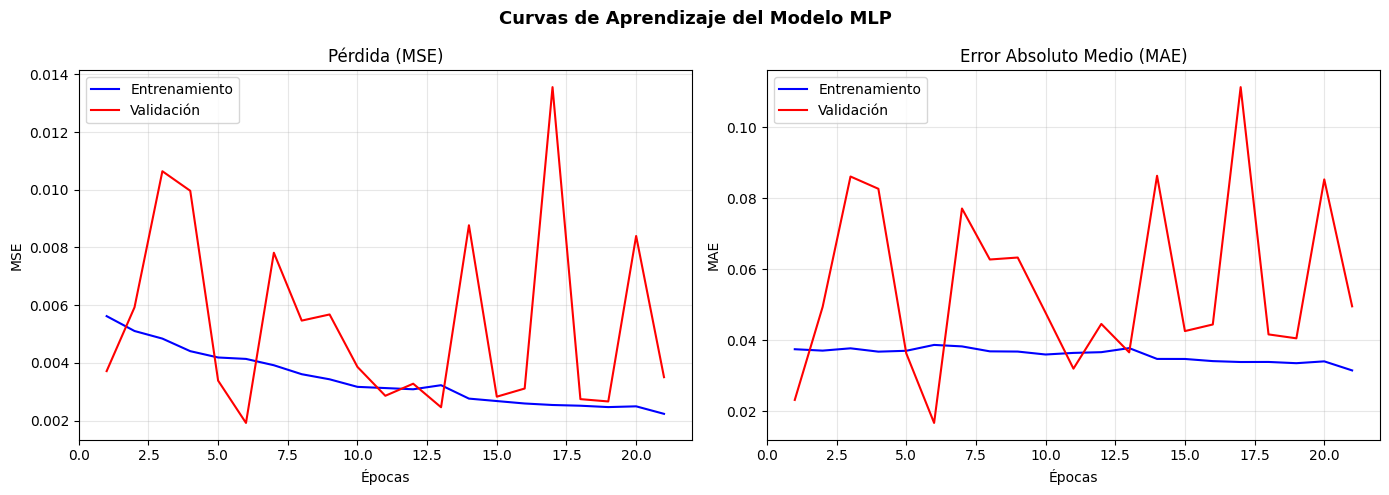

 Gráfica guardada como 02_curvas_aprendizaje.png


In [18]:
# Extraer historial de entrenamiento
loss_train = historial.history['loss']
loss_val   = historial.history['val_loss']
epocas_reales = range(1, len(loss_train) + 1)

# Crear gráfica de curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizaje del Modelo MLP', fontsize=13, fontweight='bold')

# --- Pérdida (MSE) ---
axes[0].plot(epocas_reales, loss_train, 'b-', label='Entrenamiento', linewidth=1.5)
axes[0].plot(epocas_reales, loss_val,   'r-', label='Validación',    linewidth=1.5)
axes[0].set_title('Pérdida (MSE)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- MAE ---
mae_train = historial.history['mae']
mae_val   = historial.history['val_mae']
axes[1].plot(epocas_reales, mae_train, 'b-', label='Entrenamiento', linewidth=1.5)
axes[1].plot(epocas_reales, mae_val,   'r-', label='Validación',    linewidth=1.5)
axes[1].set_title('Error Absoluto Medio (MAE)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_curvas_aprendizaje.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Gráfica guardada como 02_curvas_aprendizaje.png')

"La inestabilidad de la curva de validación se debe a la volatilidad intrínseca del mercado de divisas en el período 2019–2022 (COVID-19, conflicto Rusia-Ucrania), que generó movimientos atípicos no presentes en los datos de entrenamiento. El Early Stopping restauró los pesos de la época 6 donde el modelo tuvo su mejor generalización (val_loss = 0.0019)."

## 12: Evaluación del modelo en el conjunto de Test

Ahora evaluamos el modelo con los datos de **test** que el modelo nunca vio durante el entrenamiento. Esto nos da una medida real de qué tan bien funciona el modelo en datos nuevos.

Usamos 3 métricas:
- **RMSE (Root Mean Squared Error):** error promedio en la misma unidad que el precio (USD)
- **MAE (Mean Absolute Error):** error absoluto promedio
- **R² (Coeficiente de determinación):** qué tan bien explica el modelo la variación (1.0 = perfecto)

In [19]:
# Hacer predicciones sobre el conjunto de test
y_pred_norm = modelo.predict(X_test, verbose=0)

# Invertir la normalización para obtener precios reales en USD
# Necesitamos reshape para que el scaler pueda procesar los datos
y_pred_real = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Calcular métricas de error
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))  # Raíz del error cuadrático medio
mae  = mean_absolute_error(y_test_real, y_pred_real)           # Error absoluto medio
r2   = r2_score(y_test_real, y_pred_real)                      # Coeficiente de determinación

# Mostrar resultados
print('=' * 50)
print(' RESULTADOS EN CONJUNTO DE TEST')
print('=' * 50)
print(f'  RMSE (error promedio en USD): {rmse:.4f}')
print(f'  MAE  (error absoluto medio) : {mae:.4f}')
print(f'  R²   (ajuste del modelo)    : {r2:.4f}')
print('=' * 50)
print(f'\n  Interpretación:')
print(f'  El modelo se equivoca en promedio ±{mae:.4f} USD por 1 Euro')
print(f'  El modelo explica el {r2*100:.1f}% de la variación del precio')

 RESULTADOS EN CONJUNTO DE TEST
  RMSE (error promedio en USD): 0.0133
  MAE  (error absoluto medio) : 0.0108
  R²   (ajuste del modelo)    : 0.9314

  Interpretación:
  El modelo se equivoca en promedio ±0.0108 USD por 1 Euro
  El modelo explica el 93.1% de la variación del precio


## 13: Visualización de predicciones vs valores reales

Graficamos los precios reales del EUR/USD contra las predicciones del modelo para el conjunto de test. Esta es la gráfica más importante: nos permite ver visualmente qué tan bien sigue el modelo el comportamiento real del mercado.

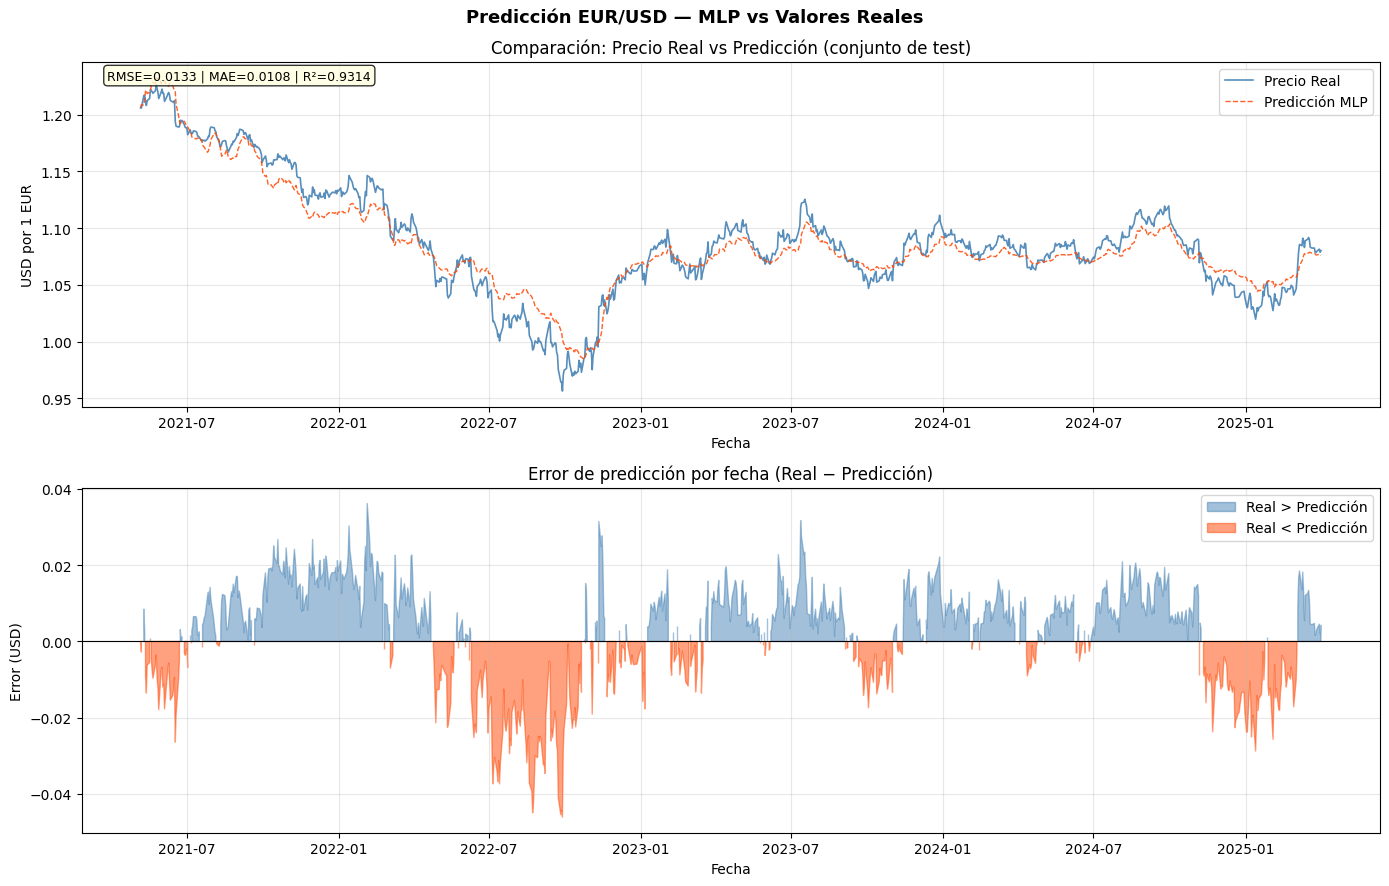

 Gráfica guardada como 03_predicciones_vs_real.png


In [20]:
# Convertir fechas a formato datetime para graficar
fechas_test_dt = pd.to_datetime(fechas_test)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Predicción EUR/USD — MLP vs Valores Reales', fontsize=13, fontweight='bold')

# --- Gráfica 1: Líneas superpuestas ---
axes[0].plot(fechas_test_dt, y_test_real, color='steelblue', linewidth=1.2,
             label='Precio Real', alpha=0.9)
axes[0].plot(fechas_test_dt, y_pred_real, color='orangered', linewidth=1.0,
             label='Predicción MLP', alpha=0.85, linestyle='--')
axes[0].set_title('Comparación: Precio Real vs Predicción (conjunto de test)')
axes[0].set_ylabel('USD por 1 EUR')
axes[0].set_xlabel('Fecha')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Agregar texto con métricas en la gráfica
axes[0].text(0.02, 0.95, f'RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}',
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Gráfica 2: Error de predicción por fecha ---
error = y_test_real - y_pred_real
axes[1].fill_between(fechas_test_dt, error, 0,
                     where=(error >= 0), color='steelblue', alpha=0.5, label='Real > Predicción')
axes[1].fill_between(fechas_test_dt, error, 0,
                     where=(error < 0),  color='orangered', alpha=0.5, label='Real < Predicción')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Error de predicción por fecha (Real − Predicción)')
axes[1].set_ylabel('Error (USD)')
axes[1].set_xlabel('Fecha')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_predicciones_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Gráfica guardada como 03_predicciones_vs_real.png')

## 14: Predicción de días futuros

Finalmente, usamos el modelo para **predecir los próximos 30 días** a partir del último dato disponible en el dataset. Esto demuestra la capacidad del modelo para **inferir valores futuros** como pide el laboratorio.

El proceso es iterativo:
1. Tomamos los últimos 30 días conocidos
2. Predecimos el día 31
3. Añadimos esa predicción a la ventana
4. Repetimos para el día 32, 33, etc.

In [21]:
DIAS_FUTUROS = 30   # Cuántos días hacia adelante predecir

# Tomar los últimos 30 días del dataset como punto de partida
ultima_ventana = valores_norm[-VENTANA:].flatten().tolist()

predicciones_futuras_norm = []  # Guardar predicciones normalizadas

# Predecir iterativamente día por día
for _ in range(DIAS_FUTUROS):
    # Preparar la ventana actual con la forma que espera el modelo
    entrada = np.array(ultima_ventana[-VENTANA:]).reshape(1, -1)
    # Predecir el siguiente valor
    siguiente = modelo.predict(entrada, verbose=0)[0][0]
    # Guardar la predicción
    predicciones_futuras_norm.append(siguiente)
    # Agregar la predicción a la ventana para el siguiente paso
    ultima_ventana.append(siguiente)

# Invertir la normalización para obtener precios reales
pred_futuras_real = scaler.inverse_transform(
    np.array(predicciones_futuras_norm).reshape(-1, 1)
).flatten()

# Crear fechas futuras (días hábiles, excluyendo fines de semana)
ultima_fecha = df['fecha'].max()
fechas_futuras = pd.bdate_range(start=ultima_fecha + pd.Timedelta(days=1), periods=DIAS_FUTUROS)

# Mostrar tabla de predicciones futuras
df_futuro = pd.DataFrame({
    'Fecha'      : fechas_futuras.date,
    'EUR_USD_pred': np.round(pred_futuras_real, 4)
})
print(f' Predicciones para los próximos {DIAS_FUTUROS} días hábiles:')
print(df_futuro.to_string(index=False))

 Predicciones para los próximos 30 días hábiles:
     Fecha  EUR_USD_pred
2025-04-03        1.0763
2025-04-04        1.0753
2025-04-07        1.0741
2025-04-08        1.0731
2025-04-09        1.0728
2025-04-10        1.0725
2025-04-11        1.0727
2025-04-14        1.0722
2025-04-15        1.0713
2025-04-16        1.0712
2025-04-17        1.0712
2025-04-18        1.0707
2025-04-21        1.0706
2025-04-22        1.0708
2025-04-23        1.0707
2025-04-24        1.0708
2025-04-25        1.0707
2025-04-28        1.0705
2025-04-29        1.0705
2025-04-30        1.0705
2025-05-01        1.0706
2025-05-02        1.0704
2025-05-05        1.0706
2025-05-06        1.0708
2025-05-07        1.0708
2025-05-08        1.0708
2025-05-09        1.0709
2025-05-12        1.0708
2025-05-13        1.0709
2025-05-14        1.0709


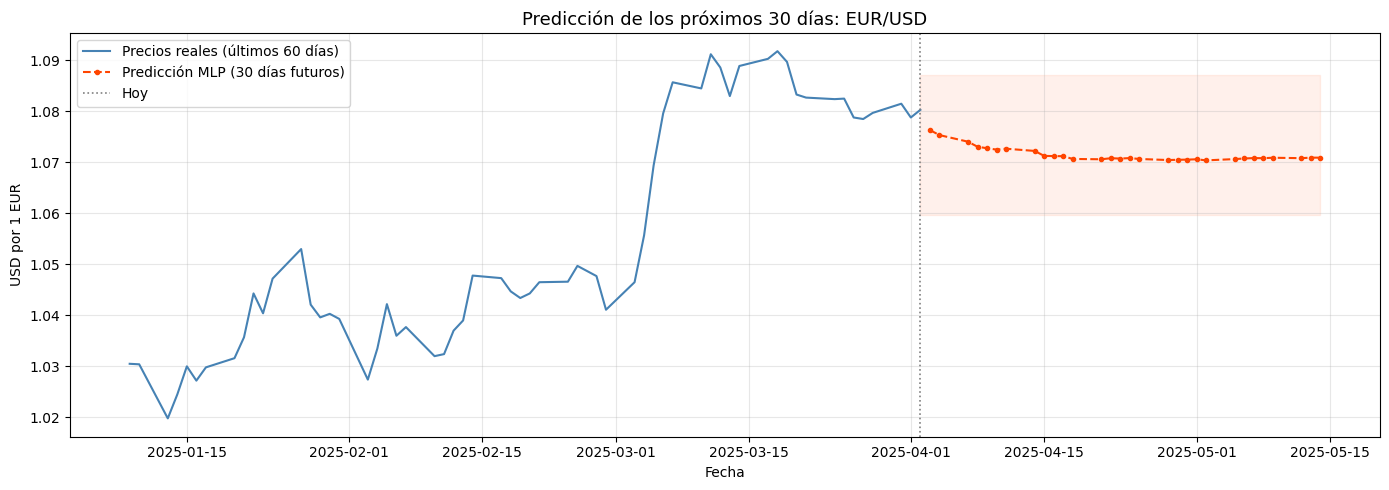

📈 Gráfica guardada como 04_prediccion_futura.png


In [22]:
# Graficar: últimos 60 días reales + 30 días predichos
ultimos_60_vals  = scaler.inverse_transform(valores_norm[-60:]).flatten()
ultimos_60_fechas = df['fecha'].values[-60:]

plt.figure(figsize=(14, 5))
plt.plot(ultimos_60_fechas, ultimos_60_vals,
         color='steelblue', linewidth=1.5, label='Precios reales (últimos 60 días)')
plt.plot(fechas_futuras, pred_futuras_real,
         color='orangered', linewidth=1.5, linestyle='--',
         marker='o', markersize=3, label=f'Predicción MLP ({DIAS_FUTUROS} días futuros)')

# Línea vertical que separa lo real de lo predicho
plt.axvline(df['fecha'].max(), color='gray', linestyle=':', linewidth=1.2, label='Hoy')
plt.fill_betweenx(
    [pred_futuras_real.min() * 0.99, pred_futuras_real.max() * 1.01],
    df['fecha'].max(), fechas_futuras[-1],
    alpha=0.08, color='orangered'
)

plt.title(f'Predicción de los próximos {DIAS_FUTUROS} días: EUR/USD', fontsize=13)
plt.ylabel('USD por 1 EUR')
plt.xlabel('Fecha')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('04_prediccion_futura.png', dpi=120, bbox_inches='tight')
plt.show()
print('📈 Gráfica guardada como 04_prediccion_futura.png')

##  15: Resumen final

Este notebook implementó un modelo MLP para predecir la cotización EUR/USD.

In [24]:
print('=' * 60)
print('  RESUMEN FINAL — Laboratorio 03')
print('  Estudiante: Claudia Pereira Cuba')
print('=' * 60)
print()
print('DATASET:')
print(f'  Nombre    : Daily Exchange Rates per Euro 1999-2025')
print(f'  Fuente    : European Central Bank via Kaggle')
print(f'  Moneda    : EUR/USD (Euro frente al Dólar Americano)')
print(f'  Registros : {len(df):,} días hábiles')
print(f'  Período   : {df["fecha"].min().date()} → {df["fecha"].max().date()}')
print()
print('PREPROCESAMIENTO:')
print('   Eliminación de valores nulos (días feriados)')
print('   Normalización MinMaxScaler [0,1]')
print(f'  Ventanas deslizantes de {VENTANA} días')
print('   División temporal Train/Val/Test (70/15/15)')
print()
print('ARQUITECTURA MLP:')
print(f'  Entrada    : {VENTANA} neuronas')
print('  Capa 1     : 128 neuronas + BatchNorm + Dropout(0.3) + L2')
print('  Capa 2     :  64 neuronas + BatchNorm + Dropout(0.2) + L2')
print('  Capa 3     :  32 neuronas + L2')
print('  Salida     :   1 neurona (precio predicho)')
print()
print('TÉCNICAS DE REGULARIZACIÓN:')
print(f'   L2 (lambda={L2_LAMBDA})')
print(f'   Dropout ({DROPOUT_1} y {DROPOUT_2})')
print('   Batch Normalization')
print('   Early Stopping (paciencia=15)')
print('   ReduceLROnPlateau (paciencia=7)')
print()

print('=' * 60)

  RESUMEN FINAL — Laboratorio 03
  Estudiante: Claudia Pereira Cuba

DATASET:
  Nombre    : Daily Exchange Rates per Euro 1999-2025
  Fuente    : European Central Bank via Kaggle
  Moneda    : EUR/USD (Euro frente al Dólar Americano)
  Registros : 6,723 días hábiles
  Período   : 1999-01-04 → 2025-04-02

PREPROCESAMIENTO:
   Eliminación de valores nulos (días feriados)
   Normalización MinMaxScaler [0,1]
  Ventanas deslizantes de 30 días
   División temporal Train/Val/Test (70/15/15)

ARQUITECTURA MLP:
  Entrada    : 30 neuronas
  Capa 1     : 128 neuronas + BatchNorm + Dropout(0.3) + L2
  Capa 2     :  64 neuronas + BatchNorm + Dropout(0.2) + L2
  Capa 3     :  32 neuronas + L2
  Salida     :   1 neurona (precio predicho)

TÉCNICAS DE REGULARIZACIÓN:
   L2 (lambda=0.001)
   Dropout (0.3 y 0.2)
   Batch Normalization
   Early Stopping (paciencia=15)
   ReduceLROnPlateau (paciencia=7)

